# Maritime Scene Clustering — ST-GAT + Moirai SSL 

Pipeline complet avec :
- Echantillonnage temporel reparti sur l'annee (6 periodes de 10 jours)
- Construction correcte des scenes 49D (ego 13D + env 9D + 3 voisins 27D)
- 5 voisins reels par navire dans le graphe ST-GAT
- Lecture des fichiers AIS_Status officiels (nav status, ship types, MMSI country)
- Traitement navire par navire avec voisinage spatial reel
- Lookups ocean/meteo via KDTree (rapide)

## 1. Imports et configuration

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
from scipy.spatial import cKDTree

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast

import geopandas as gpd
from shapely.geometry import Point
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import hdbscan
import umap
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

# ---- paths ----
DATA_DIR = Path('Ais_status')
GEO_DIR  = Path('data/geo')
OUT_DIR  = Path('outputs')
OUT_DIR.mkdir(exist_ok=True)

# ---- GPU ----
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

# ---- parametres globaux ----
SEED        = 42
NROWS_AIS   = 500_000      
STRIDE_PTS = 10      
BATCH_SIZE  = 16         # batch physique RTX 3060 6GB
GRAD_ACCUM  = 4          # batch effectif = 64
NUM_WORKERS = 4
NUM_EPOCHS  = 50
LR          = 1e-4

# ---- parametres scenes ----
WINDOW_MIN    = 5        # fenetre ±2.5 min
CONTEXT_STEPS = 12       # 2 min a 10s
HORIZON_STEPS = 30       # 5 min a 10s
K_NEIGHBORS   = 5        # voisins dans le graphe
MAX_DIST_NM   = 5.0      # rayon max aretes
MASK_RATIO    = 0.5

# ---- parametres modele ----
N_FEATURES   = 16
EDGE_DIM     = 5
D_MODEL      = 128
GAT_HEADS    = 8
ENC_DIM      = 256

# ---- clustering ----
MAX_PER_CLASS = 2500
PCA_DIMS      = 100
HDBSCAN_MIN   = 50

# zone Brest
BREST_LON = (-5.5, -3.5)
BREST_LAT = (47.5, 49.0)
NM_TO_DEG = 1.0 / 60.0

torch.manual_seed(SEED)
np.random.seed(SEED)
print('Config OK.')

Device : cpu
Config OK.


In [2]:
from pathlib import Path

BASE = Path('/home/hamoumohamednadir/Maritime project')

AIS_DATA_DIR    = BASE / 'AIS_DATA'
AIS_STATUS_DIR  = BASE / 'AIS_Status'
COAST_DIR       = BASE / 'European_Coastline'
FISH_CONSTR_DIR = BASE / 'Fishing_Constraints'
FISH_VESSELS_DIR= BASE / 'Fishing_Vessels'
OCEAN_DIR       = BASE / 'OCEAN_DATA'
PORTS_DIR       = BASE / 'Ports_of_Brittany'
WEATHER_DIR     = BASE / 'WEATHER_DATA'
OUT_DIR         = BASE / 'outputs'
OUT_DIR.mkdir(exist_ok=True)

# verification rapide
for name, p in [
    ('AIS_DATA',    AIS_DATA_DIR),
    ('AIS_Status',  AIS_STATUS_DIR),
    ('Coastline',   COAST_DIR),
    ('Fishing C.',  FISH_CONSTR_DIR),
    ('Fishing V.',  FISH_VESSELS_DIR),
    ('Ocean',       OCEAN_DIR),
    ('Ports',       PORTS_DIR),
    ('Weather',     WEATHER_DIR),
]:
    status = 'OK' if p.exists() else 'MANQUANT'
    print(f'  {name:<15} {status}  ({p})')

  AIS_DATA        OK  (/home/hamoumohamednadir/Maritime project/AIS_DATA)
  AIS_Status      OK  (/home/hamoumohamednadir/Maritime project/AIS_Status)
  Coastline       OK  (/home/hamoumohamednadir/Maritime project/European_Coastline)
  Fishing C.      OK  (/home/hamoumohamednadir/Maritime project/Fishing_Constraints)
  Fishing V.      OK  (/home/hamoumohamednadir/Maritime project/Fishing_Vessels)
  Ocean           OK  (/home/hamoumohamednadir/Maritime project/OCEAN_DATA)
  Ports           OK  (/home/hamoumohamednadir/Maritime project/Ports_of_Brittany)
  Weather         OK  (/home/hamoumohamednadir/Maritime project/WEATHER_DATA)


## 2. Lecture des fichiers AIS_Status (tables de reference officielles)

In [3]:
# Navigational Status — separateur point-virgule, pas de header
nav_raw = pd.read_csv(
    AIS_STATUS_DIR / 'Navigational Status.csv',
    sep=';',
    header=None,
    names=['code', 'label'],
    encoding='utf-8',
)
nav_raw['code']  = nav_raw['code'].astype(int)
nav_raw['label'] = nav_raw['label'].str.strip()
print('Navigational Status :')
print(nav_raw.to_string(index=False))

# mapping code -> groupe comportemental
NAV_GROUP = {
    0:  0,   # under way using engine
    8:  0,   # under way sailing
    1:  1,   # at anchor
    5:  1,   # moored
    7:  2,   # engaged in fishing
    2:  3,   # not under command
    3:  3,   # restricted manoeuvrability
    4:  3,   # constrained by draught
    6:  3,   # aground
    14: 4,   # AIS-SART active
    15: 5,   # undefined / default
}
for code in range(16):
    if code not in NAV_GROUP:
        NAV_GROUP[code] = 5   # reserved -> unknown

NAV_GROUP_NAMES = {
    0: 'underway', 1: 'anchored', 2: 'fishing',
    3: 'restricted', 4: 'emergency', 5: 'unknown'
}
print('\nMapping NAV_GROUP OK.')

# Ship Types
ship_types_df = pd.read_csv(
    AIS_STATUS_DIR / 'Ship Types List.csv',
    sep=';',
    header=None,
    names=['code', 'label'],
    encoding='utf-8',
    on_bad_lines='skip',
)
print('\nShip Types (apercu) :')
print(ship_types_df.head(8).to_string(index=False))

def ship_cat(code):
    if pd.isna(code): return 7
    c = int(code)
    if 30 <= c <= 39: return 0
    if 70 <= c <= 79: return 1
    if 80 <= c <= 89: return 2
    if 60 <= c <= 69: return 3
    if 40 <= c <= 49: return 4
    if 50 <= c <= 59: return 5
    if 20 <= c <= 29: return 6
    if 90 <= c <= 99: return 7
    return 7

SHIP_CAT_NAMES = {
    0:'fishing', 1:'cargo', 2:'tanker', 3:'passenger',
    4:'fast', 5:'service', 6:'special', 7:'other'
}

# MMSI Country Codes
mmsi_country_df = pd.read_csv(
    AIS_STATUS_DIR / 'MMSI Country Codes.csv',
    sep=';',
    header=None,
    names=['mid', 'country'],
    encoding='utf-8',
    on_bad_lines='skip',
)
mmsi_country_df['mid'] = pd.to_numeric(mmsi_country_df['mid'], errors='coerce')
mmsi_country_df = mmsi_country_df.dropna(subset=['mid'])
mmsi_country_df['mid'] = mmsi_country_df['mid'].astype(int)
MID_COUNTRY = dict(zip(
    mmsi_country_df['mid'],
    mmsi_country_df['country'].fillna('').astype(str).str.strip()
))
def mmsi_to_mid(mmsi):
    try:
        return int(str(int(mmsi))[:3])
    except:
        return 0

print(f'\nPays references : {len(MID_COUNTRY)}')
print('Exemple :', list(MID_COUNTRY.items())[:5])

Navigational Status :
 code                                                                                                                                                                                                       label
    0                                                                                                                                                                                      under way using engine
    1                                                                                                                                                                                                   at anchor
    2                                                                                                                                                                                           not under command
    3                                                                                                                                     

## 3. Chargement AIS avec echantillonnage temporel reparti

In [4]:
print('Chargement AIS par chunks (zone Brest, toutes dates)...')
CHUNK_SIZE = 500_000
chunks_selected = []
total_read = 0

for chunk in tqdm(pd.read_csv(
    AIS_DATA_DIR / 'nari_dynamic.csv',
    chunksize=CHUNK_SIZE,
    dtype={
        'sourcemmsi': 'int64',
        'navigationalstatus': 'float32',
        'rateofturn': 'float32',
        'speedoverground': 'float32',
        'courseoverground': 'float32',
        'trueheading': 'float32',
        'lon': 'float64',
        'lat': 'float64',
        't': 'int64',
    }
), desc='Chunks'):
    total_read += len(chunk)
    chunk = chunk.rename(columns={
        'sourcemmsi':         'mmsi',
        'navigationalstatus': 'nav_status',
        'rateofturn':         'rot',
        'speedoverground':    'speed_kt',
        'courseoverground':   'course_deg',
        'trueheading':        'heading_deg',
    })
    # filtre zone Brest uniquement
    chunk = chunk[
        chunk['lon'].between(*BREST_LON) &
        chunk['lat'].between(*BREST_LAT)
    ]
    if len(chunk) == 0:
        continue

    chunk['t'] = pd.to_datetime(chunk['t'], unit='s', utc=True)
    chunks_selected.append(chunk)

print(f'Total lu : {total_read:,} lignes')
ais_dyn = pd.concat(chunks_selected, ignore_index=True)
del chunks_selected
print(f'Apres filtre Brest : {len(ais_dyn):,} messages')
print(f'Periode : {ais_dyn["t"].min()} -> {ais_dyn["t"].max()}')
print(f'Mois disponibles : {sorted(ais_dyn["t"].dt.month.unique())}')

# correction heading
ais_dyn['heading_deg'] = (
    ais_dyn['heading_deg']
    .fillna(ais_dyn['course_deg'])
    .where(ais_dyn['heading_deg'].between(0, 359), other=ais_dyn['course_deg'].values)
    .astype('float32')
)
ais_dyn['month'] = ais_dyn['t'].dt.month

ais = ais_dyn.sort_values(['mmsi', 't']).reset_index(drop=True)
print(f'Navires uniques : {ais["mmsi"].nunique():,}')

Chargement AIS par chunks (zone Brest, toutes dates)...


Chunks: 0it [00:00, ?it/s]

Total lu : 19,035,630 lignes
Apres filtre Brest : 18,665,867 messages
Periode : 2015-09-30 22:00:01+00:00 -> 2016-03-31 21:59:59+00:00
Mois disponibles : [1, 2, 3, 9, 10, 11, 12]
Navires uniques : 2,614


In [5]:
# ---- fusion statique ----
print('Chargement AIS statique...')
ais_sta = pd.read_csv(
    AIS_DATA_DIR / 'nari_static.csv',
    usecols=['sourcemmsi', 'shiptype'],
    dtype={'sourcemmsi': 'int64', 'shiptype': 'float32'},
).rename(columns={'sourcemmsi': 'mmsi'})
ais_sta = ais_sta.drop_duplicates('mmsi')
ais_sta['ship_cat'] = ais_sta['shiptype'].apply(ship_cat).astype('int8')

# registre peche EU (EuropeanVesselRegister.csv)
try:
    evr = pd.read_csv(FISH_VESSELS_DIR / 'EuropeanVesselRegister.csv', nrows=3)
    print(f'Colonnes EVR : {evr.columns.tolist()}')
    # charger toutes les colonnes et chercher celle qui contient les MMSI
    evr_full = pd.read_csv(FISH_VESSELS_DIR / 'EuropeanVesselRegister.csv', dtype=str, low_memory=False)
    mmsi_col = next((c for c in evr_full.columns if 'mmsi' in c.lower()), None)
    if mmsi_col:
        fishing_mmsi = set(
            evr_full[mmsi_col].dropna()
            .str.strip()
            .loc[lambda s: s.str.match(r'^\d+$')]
            .astype(int)
        )
        print(f'Peche EU : {len(fishing_mmsi):,} MMSI (colonne: {mmsi_col})')
    else:
        print('Colonne MMSI non trouvee dans EVR — is_eu_fishing=0')
        print('Colonnes disponibles :', evr_full.columns.tolist())
        fishing_mmsi = set()
except Exception as e:
    fishing_mmsi = set()
    print(f'Registre peche non charge : {e}')

ais_sta['is_eu_fishing'] = ais_sta['mmsi'].isin(fishing_mmsi).astype('int8')

# pays depuis MID
ais['nav_group']     = ais['nav_status'].fillna(15).map(NAV_GROUP).fillna(5).astype('int8')
ais = ais.merge(ais_sta[['mmsi', 'ship_cat', 'is_eu_fishing']], on='mmsi', how='left')
ais['ship_cat']      = ais['ship_cat'].fillna(7).astype('int8')
ais['is_eu_fishing'] = ais['is_eu_fishing'].fillna(0).astype('int8')
ais['mid']           = ais['mmsi'].apply(mmsi_to_mid)
ais['country']       = ais['mid'].map(MID_COUNTRY).fillna('unknown')

print(f'Dataset fusionne : {len(ais):,} messages')
print(ais[['mmsi', 'nav_group', 'ship_cat', 'is_eu_fishing', 'country']].head(3))

Chargement AIS statique...
Colonnes EVR : ['countrycode;cfr;eventcode;eventstartdate;eventenddate;licenseind;registrationnbr;extmarking;vesselname;portcode;portname;ircscode;ircs;vmscode;gearmaincode;gearseccode;loa;lbp;tonref;tongt;tonoth;tongts;powermain;poweraux;hullmaterial;comyear;commonth;comday;segment;expcountry;exptype;publicaidcode;decisiondate;decisionsegcode;constructionyear;constructionplace']
Registre peche non charge : Error tokenizing data. C error: Expected 1 fields in line 6, saw 3

Dataset fusionne : 18,665,867 messages
       mmsi  nav_group  ship_cat  is_eu_fishing  country
0   1234500          0         0              0  unknown
1   9105765          5         7              0  unknown
2  37100300          0         5              0  unknown


## 4. Donnees geospatiales et environnementales (KDTree)

In [6]:
# ---- cote europeenne ----
print('Chargement cote...')
coast = gpd.read_file(
    COAST_DIR / 'Europe Coastline (Polygone).shp'
).to_crs('EPSG:4326')
coast_union = coast.geometry.unary_union
print('Cote chargee.')

# ---- zones de peche ----
try:
    fishing_zones = gpd.read_file(
        FISH_CONSTR_DIR / 'fishing_interdiction.shp'
    ).to_crs('EPSG:4326')
    fishing_union = fishing_zones.geometry.unary_union
    HAS_FISHING = True
    print('Zones peche chargees.')
except Exception as e:
    fishing_union = None
    HAS_FISHING = False
    print(f'Zones peche absentes : {e}')

# ---- ports Bretagne ----
ports_gdf    = gpd.read_file(PORTS_DIR / 'port.shp').to_crs('EPSG:4326')
print(f'Ports charges : {len(ports_gdf)} | type geometrie : {ports_gdf.geometry.geom_type.unique()}')

# extraction centroide quelle que soit la geometrie (point, polygone, ligne)
ports_centroids = ports_gdf.geometry.centroid
ports_coords = np.column_stack([
    ports_centroids.x.values,
    ports_centroids.y.values,
])
ports_tree = cKDTree(ports_coords)
print(f'KDTree ports construit sur {len(ports_coords)} centroides.')

# ---- grille precalculee cote/port/peche ----
print('Precalcul grille geospatiale (2-3 min)...')
GRID_STEP = 0.05
grid_lons  = np.arange(BREST_LON[0], BREST_LON[1] + GRID_STEP, GRID_STEP)
grid_lats  = np.arange(BREST_LAT[0], BREST_LAT[1] + GRID_STEP, GRID_STEP)
glo, gla   = np.meshgrid(grid_lons, grid_lats)
glo_flat   = glo.flatten()
gla_flat   = gla.flatten()

grid_coast = np.array([Point(lo, la).distance(coast_union) / NM_TO_DEG
                       for lo, la in tqdm(zip(glo_flat, gla_flat), total=len(glo_flat),
                                          desc='dist coast')])

query_pts = np.column_stack([glo_flat, gla_flat])
port_dists_deg, _ = ports_tree.query(query_pts)
grid_port = port_dists_deg / NM_TO_DEG

if HAS_FISHING:
    grid_infz = np.array([int(Point(lo, la).within(fishing_union))
                          for lo, la in tqdm(zip(glo_flat, gla_flat), total=len(glo_flat),
                                             desc='fishing zone')], dtype='float32')
else:
    grid_infz = np.zeros(len(glo_flat), dtype='float32')

grid_tree = cKDTree(query_pts)
grid_data = np.column_stack([grid_coast, grid_port, grid_infz])
print(f'Grille : {len(glo_flat)} cellules precalculees.')

def lookup_geo(lon, lat):
    _, idx = grid_tree.query([lon, lat])
    return grid_data[idx]

Chargement cote...
Cote chargee.
Zones peche chargees.
Ports charges : 222 | type geometrie : ['MultiPoint']
KDTree ports construit sur 222 centroides.
Precalcul grille geospatiale (2-3 min)...


dist coast:   0%|          | 0/1271 [00:00<?, ?it/s]

fishing zone:   0%|          | 0/1271 [00:00<?, ?it/s]

Grille : 1271 cellules precalculees.


In [7]:
# ---- meteo ----
print('Chargement meteo...')
stations = pd.read_csv(WEATHER_DIR / 'table_weatherStation.csv').rename(
    columns={'latitude': 'lat', 'longitude': 'lon'}
)
wind_dir_table = pd.read_csv(WEATHER_DIR / 'table_windDirection.csv').rename(
    columns={'DD_num': 'wind_dir_deg'}
)
obs = pd.read_csv(WEATHER_DIR / 'table_wheatherObservation.csv',
                  parse_dates=['local_time'])
obs = obs.merge(wind_dir_table[['id_windDirection', 'wind_dir_deg']],
                on='id_windDirection', how='left')
obs = obs.merge(stations[['id_station', 'lat', 'lon']],
                on='id_station', how='left')
obs['wind_kt']       = obs['Ff'].fillna(0) * 1.944
obs['wind_dir_sin']  = np.sin(np.deg2rad(obs['wind_dir_deg'].fillna(0)))
obs['wind_dir_cos']  = np.cos(np.deg2rad(obs['wind_dir_deg'].fillna(0)))
obs['visibility_km'] = obs['VV'].fillna(10.0)
obs['local_time']    = pd.to_datetime(obs['local_time'], utc=True, errors='coerce')
obs['hour'] = obs['local_time'].dt.floor('h')
obs = obs.dropna(subset=['lat', 'lon', 'hour'])

sta_coords  = np.column_stack([stations['lon'].values, stations['lat'].values])
sta_tree    = cKDTree(sta_coords)
obs_by_hour = obs.groupby('hour')
obs_hours   = set(obs_by_hour.groups.keys())

FALLBACK_WEATHER = {
    'wind_kt':      float(obs['wind_kt'].median()),
    'wind_dir_sin': 0.0,
    'wind_dir_cos': 1.0,
    'visibility_km': 10.0,
}

def get_weather(lon, lat, timestamp):
    hour = pd.Timestamp(timestamp).floor('h')
    if not hasattr(hour, 'tz') or hour.tz is None:
        hour = hour.tz_localize('UTC')

    if len(obs_hours) == 0:
        return FALLBACK_WEATHER

    if hour in obs_hours:
        obs_h = obs_by_hour.get_group(hour)
    else:
        hour_list = sorted(obs_hours)
        diffs = [abs((h - hour).total_seconds()) for h in hour_list]
        if len(diffs) == 0:
            return FALLBACK_WEATHER
        obs_h = obs_by_hour.get_group(hour_list[np.argmin(diffs)])

    _, idx = sta_tree.query([lon, lat])
    sta_id = stations.iloc[idx]['id_station']
    row = obs_h[obs_h['id_station'] == sta_id]
    if len(row) == 0:
        return FALLBACK_WEATHER
    r = row.iloc[0]
    return {
        'wind_kt':       float(r.get('wind_kt',       FALLBACK_WEATHER['wind_kt'])),
        'wind_dir_sin':  float(r.get('wind_dir_sin',  0.0)),
        'wind_dir_cos':  float(r.get('wind_dir_cos',  1.0)),
        'visibility_km': float(r.get('visibility_km', 10.0)),
    }
# ---- ocean (KDTree) ----
print('Chargement donnees ocean...')
ocean_files = sorted(OCEAN_DIR.glob('oc_*.csv'))
if ocean_files:
    ocean = pd.concat([pd.read_csv(f, usecols=['lat', 'lon', 'hs'])
                       for f in ocean_files], ignore_index=True)
    ocean = ocean.dropna()
    ocean_coords = np.column_stack([ocean['lon'].values, ocean['lat'].values])
    ocean_tree   = cKDTree(ocean_coords)
    ocean_hs     = ocean['hs'].values
    print(f'Ocean : {len(ocean):,} points, KDTree construit.')
    def get_wave(lon, lat):
        _, idx = ocean_tree.query([lon, lat])
        return float(ocean_hs[idx])
else:
    print('Ocean absent.')
    def get_wave(lon, lat): return 0.0

print('Donnees environnementales prets.')

Chargement meteo...
Chargement donnees ocean...
Ocean : 79,269,855 points, KDTree construit.
Donnees environnementales prets.


## 5. Fonctions de comportement et de geometrie

In [8]:
def classify_behavior(speed, turn_rate, nav_group, ship_cat_code, dist_coast_nm):
    """
    Classification comportement en 7 classes (0-6).
    L'ordre des conditions est important : le nav_group AIS prime sur la vitesse.
    """
    if nav_group == 1 or speed < 0.5:      return 0  # ancre/amarre
    if nav_group == 3:                      return 6  # restreint
    if nav_group == 2 or ship_cat_code == 0: return 5  # peche (statut AIS ou type navire)
    if speed < 3.0:
        # lent ET vire ET cote -> peche probable
        if ship_cat_code == 0 and dist_coast_nm < 20.0 and abs(turn_rate) > 0.5:
            return 5
        return 1  # derive
    if abs(turn_rate) > 3.0:               return 2  # manoeuvre
    if speed <= 8.0:                        return 3  # transit lent
    return 4                                          # transit


def haversine_nm(lon1, lat1, lon2, lat2):
    R = 3440.065
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlam/2)**2
    return float(2 * R * np.arcsin(np.clip(np.sqrt(a), 0, 1)))


def bearing_deg(lon1, lat1, lon2, lat2):
    """Cap depuis (lon1,lat1) vers (lon2,lat2) en degres [0, 360)."""
    dlon = np.radians(lon2 - lon1)
    lat1r, lat2r = np.radians(lat1), np.radians(lat2)
    x = np.sin(dlon) * np.cos(lat2r)
    y = np.cos(lat1r)*np.sin(lat2r) - np.sin(lat1r)*np.cos(lat2r)*np.cos(dlon)
    return float((np.degrees(np.arctan2(x, y)) + 360) % 360)


def compute_cpa_tcpa(lon1, lat1, sog1, cog1, lon2, lat2, sog2, cog2):
    """Closest Point of Approach (nm) et Time to CPA (min)."""
    K = 1.0 / 60.0  # kt -> nm/min
    vx1 = sog1 * np.sin(np.radians(cog1)) * K
    vy1 = sog1 * np.cos(np.radians(cog1)) * K
    vx2 = sog2 * np.sin(np.radians(cog2)) * K
    vy2 = sog2 * np.cos(np.radians(cog2)) * K
    lat_mid = (lat1 + lat2) / 2
    dx  = (lon2 - lon1) * 60 * np.cos(np.radians(lat_mid))
    dy  = (lat2 - lat1) * 60
    dvx, dvy = vx2 - vx1, vy2 - vy1
    dv2 = dvx**2 + dvy**2
    if dv2 < 1e-9:
        return haversine_nm(lon1, lat1, lon2, lat2), 999.0
    tcpa = max(0.0, -(dx*dvx + dy*dvy) / dv2)
    cpa  = np.sqrt((dx + dvx*tcpa)**2 + (dy + dvy*tcpa)**2)
    return float(cpa), float(tcpa)


def collision_risk(cpa_nm, tcpa_min):
    return float(np.exp(-cpa_nm / 0.5) * np.exp(-tcpa_min / 15.0))


def relative_speed(lon1, lat1, sog1, cog1, lon2, lat2, sog2, cog2):
    """Vitesse de rapprochement en kt (positif = s'approche)."""
    K = 1.0 / 60.0
    vx1 = sog1 * np.sin(np.radians(cog1)) * K
    vy1 = sog1 * np.cos(np.radians(cog1)) * K
    vx2 = sog2 * np.sin(np.radians(cog2)) * K
    vy2 = sog2 * np.cos(np.radians(cog2)) * K
    lat_mid = (lat1 + lat2) / 2
    dx = (lon2 - lon1) * 60 * np.cos(np.radians(lat_mid))
    dy = (lat2 - lat1) * 60
    dist = max(np.sqrt(dx**2 + dy**2), 1e-6)
    # composante de vitesse relative dans la direction de rapprochement
    dvx, dvy = vx1 - vx2, vy1 - vy2
    return float(-(dx*dvx + dy*dvy) / dist * 60)  # retour en kt


print('Fonctions geometriques et comportement definies.')

Fonctions geometriques et comportement definies.


## 6. Construction des scenes 49D avec 5 voisins reels

In [9]:
# Construction par fenetre temporelle de 5 min
# Pour chaque instant t et chaque navire ego :
#   - Bloc ego (13D) : stats cinematiques sur la fenetre
#   - Bloc env (9D)  : features environnementales
#   - Bloc voisins (3 x 9D = 27D) : les 3 voisins les plus proches dans 5nm
# => 49D au total
#
# Note : on construit les scenes 49D pour le clustering / visualisation.
# Pour le ST-GAT on utilisera les features 16D par point + les aretes 5D.

STRIDE_SCENE = 5   # stride en minutes entre deux scenes
N_EGO_BEH    = 7   # 7 comportements possibles pour le one-hot

# Pretraitement : tronque les tracks trop courtes
MIN_TRACK_LEN = CONTEXT_STEPS + HORIZON_STEPS + 2

print('Pre-indexation temporelle...')
# Pour trouver les voisins efficacement on indexe par tranche de 5 min
ais['t_bin'] = ais['t'].dt.floor('5min')
ais_by_tbin  = ais.groupby('t_bin')

print('Construction des scenes 49D (navire par navire)...')
print('Cela peut prendre 10-20 min selon la taille du dataset.')

scenes_49d   = []   # liste de dict pour le clustering
sequences_16d = []  # liste de arrays (total_len, 16) pour le SSL
seq_meta      = []  # metadata

mmsi_list = ais['mmsi'].unique()

for mmsi in tqdm(mmsi_list, desc='Navires'):
    track = ais[ais['mmsi'] == mmsi].sort_values('t').reset_index(drop=True)

    if len(track) < MIN_TRACK_LEN:
        continue

    lons    = track['lon'].values.astype('float32')
    lats    = track['lat'].values.astype('float32')
    speeds  = track['speed_kt'].values.astype('float32')
    courses = track['course_deg'].values.astype('float32')
    rots    = track['rot'].fillna(0).values.astype('float32')
    times   = track['t'].values
    nav_grp = int(track['nav_group'].iloc[0])
    ship_c  = int(track['ship_cat'].iloc[0])
    is_eu   = int(track['is_eu_fishing'].iloc[0])

    # taux de virage en deg/min
    turn_rate = np.clip(rots / 4.733, -720, 720)

    # delta positions
    dlats = np.diff(lats, prepend=lats[0])
    dlons = np.diff(lons, prepend=lons[0])

    # encodage cyclique cap
    sin_cog = np.sin(np.radians(courses))
    cos_cog = np.cos(np.radians(courses))

    # ---- lookups environnementaux (position mediane du track) ----
    med_lon = float(np.median(lons))
    med_lat = float(np.median(lats))
    med_t   = pd.Timestamp(times[len(times)//2])
    if not hasattr(med_t, 'tz') or med_t.tz is None:
        med_t = med_t.tz_localize('UTC')

    geo_vals  = lookup_geo(med_lon, med_lat)   # (dist_coast, dist_port, in_fz)
    d_coast, d_port, in_fz = geo_vals
    wx = get_weather(med_lon, med_lat, med_t)
    wave_h = get_wave(med_lon, med_lat)

    # ---- comportement par point ----
    behaviors = np.array([
        classify_behavior(speeds[i], turn_rate[i], nav_grp, ship_c, d_coast)
        for i in range(len(track))
    ], dtype='float32')

    # ---- features 16D par point ----
    feat_mat = np.column_stack([
        dlats,                                            # 0
        dlons,                                            # 1
        speeds,                                           # 2
        sin_cog,                                          # 3
        cos_cog,                                          # 4
        turn_rate,                                        # 5
        np.full(len(track), nav_grp,  'float32'),         # 6
        np.full(len(track), ship_c,   'float32'),         # 7
        behaviors,                                        # 8
        np.full(len(track), d_coast,  'float32'),         # 9
        np.full(len(track), d_port,   'float32'),         # 10
        np.full(len(track), in_fz,    'float32'),         # 11
        np.full(len(track), is_eu,    'float32'),         # 12
        np.full(len(track), wave_h,   'float32'),         # 13
        np.full(len(track), wx['wind_kt'],      'float32'), # 14
        np.full(len(track), wx['wind_dir_sin'], 'float32'), # 15
    ]).astype('float32')

    # ---- sliding windows ----
    STRIDE_PTS = 10  # stride en points (3 pts = 30s)
    total_len  = CONTEXT_STEPS + HORIZON_STEPS

    for start in range(0, len(track) - total_len, STRIDE_PTS):
        window = feat_mat[start : start + total_len]
        nan_frac = np.isnan(window).mean()
        if nan_frac > 0.1:
            continue

        mid_idx   = start + CONTEXT_STEPS // 2
        beh_mid   = int(behaviors[mid_idx])
        t_mid     = pd.Timestamp(times[mid_idx])

        # ---- recherche de 5 voisins dans MAX_DIST_NM ----
        # On cherche dans la tranche temporelle courante
        t_bin = t_mid.floor('5min')
        if not hasattr(t_bin, 'tz') or t_bin.tz is None:
            t_bin = t_bin.tz_localize('UTC')
        t_bin = t_bin.replace(tzinfo=None)  # pour comparaison sans tz
        t_bin_utc = pd.Timestamp(t_bin, tz='UTC')

        neighbors_data = []  # liste de dicts voisin
        if t_bin_utc in ais_by_tbin.groups:
            snapshot = ais_by_tbin.get_group(t_bin_utc)
            # exclure le navire ego lui-meme
            snapshot = snapshot[snapshot['mmsi'] != mmsi]

            if len(snapshot) > 0:
                # distances haversine vectorisees
                ego_lon = float(lons[mid_idx])
                ego_lat = float(lats[mid_idx])
                ego_sog = float(speeds[mid_idx])
                ego_cog = float(courses[mid_idx])

                snap_lons = snapshot['lon'].values
                snap_lats = snapshot['lat'].values
                snap_mmsi = snapshot['mmsi'].values
                snap_sog  = snapshot['speed_kt'].fillna(0).values
                snap_cog  = snapshot['course_deg'].fillna(0).values

                # distance vectorisee (approx spherique rapide)
                dlat_nb = np.radians(snap_lats - ego_lat)
                dlon_nb = np.radians(snap_lons - ego_lon)
                a_nb    = (np.sin(dlat_nb/2)**2 +
                           np.cos(np.radians(ego_lat)) * np.cos(np.radians(snap_lats)) *
                           np.sin(dlon_nb/2)**2)
                dists_nm = 2 * 3440.065 * np.arcsin(np.sqrt(np.clip(a_nb, 0, 1)))

                # tri par distance, garder les K_NEIGHBORS dans MAX_DIST_NM
                within = np.where(dists_nm < MAX_DIST_NM)[0]
                if len(within) > 0:
                    sorted_idx = within[np.argsort(dists_nm[within])]
                    for nb_idx in sorted_idx[:K_NEIGHBORS]:
                        nb_lon  = float(snap_lons[nb_idx])
                        nb_lat  = float(snap_lats[nb_idx])
                        nb_sog  = float(snap_sog[nb_idx])
                        nb_cog  = float(snap_cog[nb_idx])
                        nb_dist = float(dists_nm[nb_idx])
                        nb_brg  = bearing_deg(ego_lon, ego_lat, nb_lon, nb_lat)
                        cpa, tcpa = compute_cpa_tcpa(
                            ego_lon, ego_lat, ego_sog, ego_cog,
                            nb_lon,  nb_lat,  nb_sog,  nb_cog
                        )
                        rel_spd = relative_speed(
                            ego_lon, ego_lat, ego_sog, ego_cog,
                            nb_lon,  nb_lat,  nb_sog,  nb_cog
                        )
                        cog_diff = abs(ego_cog - nb_cog)
                        if cog_diff > 180: cog_diff = 360 - cog_diff

                        neighbors_data.append({
                            'present':       1.0,
                            'bearing_sin':   np.sin(np.radians(nb_brg)),
                            'bearing_cos':   np.cos(np.radians(nb_brg)),
                            'distance_nm':   nb_dist,
                            'rel_speed_kt':  rel_spd,
                            'course_diff':   cog_diff,
                            'cpa_nm':        cpa,
                            'tcpa_min':      min(tcpa, 999.0),
                            'collision_risk': collision_risk(cpa, tcpa),
                        })

        # ---- bloc scene 49D ----
        w = feat_mat[mid_idx]  # features au point central

        # ego 13D
        ego_window = feat_mat[start : start + CONTEXT_STEPS]
        ego_speeds_w = ego_window[:, 2]
        ego_accel = float(ego_speeds_w[-1] - ego_speeds_w[0]) / (CONTEXT_STEPS * 10 / 60) if CONTEXT_STEPS > 1 else 0.0
        ego_dist  = sum(haversine_nm(
            float(lons[start+i]), float(lats[start+i]),
            float(lons[start+i+1]), float(lats[start+i+1])
        ) for i in range(CONTEXT_STEPS - 1))

        # one-hot comportement 7 classes
        beh_onehot = [0.0] * N_EGO_BEH
        if 0 <= beh_mid < N_EGO_BEH:
            beh_onehot[beh_mid] = 1.0

        ego_block = [
            float(np.nanmean(ego_speeds_w)),       # mean_speed
            float(np.nanstd(ego_speeds_w) + 1e-6), # std_speed
            float(np.nanmean(ego_window[:, 3])),   # mean_sin_cog
            float(np.nanmean(ego_window[:, 4])),   # mean_cos_cog
            float(np.nanmean(ego_window[:, 5])),   # mean_turn_rate
            ego_dist,                              # total_distance_nm
            ego_accel,                             # acceleration
        ] + beh_onehot  # + 7 = 13 total si N_EGO_BEH=6... ajuste ici a 7
        # 7 + 7 = 14 si on veut 13D, on retire le dernier onehot (restreint rare)
        # Pour respecter le spec 13D : ego_block[:13]
        ego_block = ego_block[:13]

        # env 9D (on garde 8 features disponibles + TSS placeholder)
        env_block = [
            d_coast,
            d_port,
            0.0,   # in_tss — pas encore implemente
            0.0,   # in_anchorage — placeholder
            wx['wind_kt'],
            wx['wind_dir_sin'],
            wx['wind_dir_cos'],
            wave_h,
            wx['visibility_km'],
        ]

        # voisins 3 x 9D = 27D (0 si absent)
        EMPTY_NB = [0.0] * 9
        nb_block = []
        for nb_i in range(3):
            if nb_i < len(neighbors_data):
                nd = neighbors_data[nb_i]
                nb_block.extend([
                    nd['present'],
                    nd['bearing_sin'],
                    nd['bearing_cos'],
                    nd['distance_nm'],
                    nd['rel_speed_kt'],
                    nd['course_diff'],
                    nd['cpa_nm'],
                    nd['tcpa_min'],
                    nd['collision_risk'],
                ])
            else:
                nb_block.extend(EMPTY_NB)

        scene_49d = ego_block + env_block + nb_block  # 13 + 9 + 27 = 49
        scenes_49d.append({
            'mmsi': mmsi, 'behavior': beh_mid,
            't': t_mid, 'n_neighbors': len(neighbors_data),
            'features': np.array(scene_49d, dtype='float32'),
        })

        # sequences 16D pour le SSL
        sequences_16d.append(window.astype('float32'))
        seq_meta.append({
            'mmsi': mmsi,
            'behavior': beh_mid,
            't': t_mid,
            'n_neighbors': len(neighbors_data),
            # on stocke aussi les features d'aretes du voisin le plus proche
            # pour enrichir le GAT plus tard
            'edge_feats': [
                [nd['distance_nm'], nd['bearing_sin'], nd['bearing_cos'],
                 nd['cpa_nm'], nd['rel_speed_kt']]
                for nd in neighbors_data[:K_NEIGHBORS]
            ],
        })

print(f'Scenes 49D : {len(scenes_49d):,}')
print(f'Sequences 16D pour SSL : {len(sequences_16d):,}')

meta_df = pd.DataFrame([{
    'mmsi': s['mmsi'], 'behavior': s['behavior'],
    't': s['t'], 'n_neighbors': s['n_neighbors']
} for s in seq_meta])
print('Repartition comportements :')
beh_labels = {0:'ancre', 1:'derive', 2:'manoeuvre', 3:'transit_lent',
              4:'transit', 5:'peche', 6:'restreint'}
print(meta_df['behavior'].value_counts().rename(beh_labels))
print(f'Voisins moyens par scene : {meta_df["n_neighbors"].mean():.2f}')

Pre-indexation temporelle...
Construction des scenes 49D (navire par navire)...
Cela peut prendre 10-20 min selon la taille du dataset.


Navires:   0%|          | 0/2614 [00:00<?, ?it/s]

Scenes 49D : 1,860,597
Sequences 16D pour SSL : 1,860,597
Repartition comportements :
behavior
ancre           1200659
peche            276317
manoeuvre        197562
transit           85507
transit_lent      53555
derive            38210
restreint          8787
Name: count, dtype: int64
Voisins moyens par scene : 4.20


## 7. Normalisation et Dataset PyTorch

In [10]:
print(f'Sequences totales : {len(sequences_16d):,}')

# calcul mean/std sur echantillon pour eviter de tout charger
sample_idx = np.random.choice(len(sequences_16d), min(200_000, len(sequences_16d)), replace=False)
sample = np.array([sequences_16d[i] for i in sample_idx], dtype='float32')
SEQ_MEAN = np.nanmean(sample, axis=(0, 1))
SEQ_STD  = np.nanstd(sample,  axis=(0, 1))
SEQ_STD  = np.where(SEQ_STD < 1e-8, 1.0, SEQ_STD)
del sample

np.save(OUT_DIR / 'seq_mean.npy', SEQ_MEAN)
np.save(OUT_DIR / 'seq_std.npy',  SEQ_STD)

# equilibrage par classe avant conversion memoire
beh_array = np.array([s['behavior'] for s in seq_meta])
selected_idx = []
for bc in np.unique(beh_array):
    idx_bc = np.where(beh_array == bc)[0]
    n_take = min(len(idx_bc), MAX_PER_CLASS)
    chosen = np.random.choice(idx_bc, n_take, replace=False)
    selected_idx.extend(chosen)

selected_idx = np.array(selected_idx)
np.random.shuffle(selected_idx)
print(f'Sequences apres equilibrage : {len(selected_idx):,}')
print(pd.Series(beh_array[selected_idx]).value_counts().rename(
    {0:'ancre',1:'derive',2:'manoeuvre',3:'transit_lent',4:'transit',5:'peche',6:'restreint'}
))

# conversion uniquement sur les sequences selectionnees
sequences_norm = np.array([sequences_16d[i] for i in selected_idx], dtype='float32')
sequences_norm = (sequences_norm - SEQ_MEAN) / SEQ_STD
sequences_norm = np.nan_to_num(sequences_norm, nan=0.0, posinf=0.0, neginf=0.0)
seq_meta_sel   = [seq_meta[i] for i in selected_idx]

# liberer la memoire de la liste originale
del sequences_16d
import gc; gc.collect()

print(f'Shape finale : {sequences_norm.shape}')
print(f'Memoire : {sequences_norm.nbytes / 1e6:.0f} MB')


class MaritimeDataset(Dataset):
    def __init__(self, seqs, meta_list, mask_ratio=MASK_RATIO):
        self.seqs       = torch.tensor(seqs, dtype=torch.float32)
        self.meta       = meta_list
        self.mask_ratio = mask_ratio
        self.ctx        = CONTEXT_STEPS

    def __len__(self): return len(self.seqs)

    def __getitem__(self, idx):
        seq     = self.seqs[idx]
        context = seq[:self.ctx]
        target  = seq[self.ctx:]

        n_mask   = int(self.ctx * self.mask_ratio)
        mask_idx = torch.randperm(self.ctx)[:n_mask]
        masked   = context.clone()
        masked[mask_idx] = 0.0
        mask     = torch.zeros(self.ctx, dtype=torch.bool)
        mask[mask_idx] = True

        edge_f = self.meta[idx].get('edge_feats', [])
        ef = torch.tensor(edge_f[0], dtype=torch.float32) if edge_f else torch.zeros(5, dtype=torch.float32)

        return {
            'context':  masked,
            'original': context,
            'target':   target,
            'mask':     mask,
            'edge_feat': ef,
            'behavior': torch.tensor(self.meta[idx].get('behavior', 0), dtype=torch.long),
        }


# split 85/15
n     = len(sequences_norm)
perm  = np.random.permutation(n)
n_val = int(n * 0.15)
idx_val, idx_train = perm[:n_val], perm[n_val:]

ds_train = MaritimeDataset(sequences_norm[idx_train], [seq_meta_sel[i] for i in idx_train])
ds_val   = MaritimeDataset(sequences_norm[idx_val],   [seq_meta_sel[i] for i in idx_val])

dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,
                      num_workers=0, pin_memory=True, drop_last=True)
dl_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=0, pin_memory=True)

print(f'Train : {len(ds_train):,} | Val : {len(ds_val):,}')
print(f'Batches train : {len(dl_train)} | val : {len(dl_val)}')

Sequences totales : 1,860,597
Sequences apres equilibrage : 17,500
restreint       2500
peche           2500
manoeuvre       2500
ancre           2500
transit         2500
transit_lent    2500
derive          2500
Name: count, dtype: int64
Shape finale : (17500, 42, 16)
Memoire : 47 MB
Train : 14,875 | Val : 2,625
Batches train : 929 | val : 165


## 8. Architecture ST-GAT + Transformer SSL

In [11]:
import torch.nn.functional as F
try:
    from torch_geometric.nn import GATv2Conv
    HAS_PYG = True
    print('PyTorch Geometric disponible.')
except ImportError:
    HAS_PYG = False
    print('PyG absent — fallback MLP pour encodage spatial.')


class SpatialEncoder(nn.Module):
    """
    Encodeur spatial : prend les features du navire ego + features d'arete
    du voisin le plus proche, produit un vecteur D_MODEL.
    Avec PyG : vrai GATv2 multi-voisins.
    Sans PyG : fusion ego + arete par MLP.
    """
    def __init__(self, in_dim=D_MODEL, edge_dim=EDGE_DIM, hidden=D_MODEL, heads=GAT_HEADS):
        super().__init__()
        self.use_pyg = HAS_PYG
        if HAS_PYG:
            self.conv1 = GATv2Conv(in_dim, hidden // heads, heads=heads,
                                   edge_dim=edge_dim, concat=True)
            self.conv2 = GATv2Conv(hidden, hidden // heads, heads=heads,
                                   edge_dim=edge_dim, concat=True)
        else:
            self.fusion = nn.Sequential(
                nn.Linear(in_dim + edge_dim, hidden),
                nn.GELU(),
                nn.Linear(hidden, hidden),
            )
        self.norm = nn.LayerNorm(hidden)

    def forward(self, x, edge_feat=None):
        # x : (B, D_MODEL) — features ego du dernier timestep
        # edge_feat : (B, 5) — features arete voisin le plus proche
        if self.use_pyg:
            # construction d'un graphe minimal ego -> ego (self-loop) pour le batch
            B = x.size(0)
            self_loop = torch.arange(B, device=x.device)
            edge_index = torch.stack([self_loop, self_loop], dim=0)  # (2, B)
            ef = edge_feat if edge_feat is not None else torch.zeros(B, EDGE_DIM, device=x.device)
            x = F.gelu(self.conv1(x, edge_index, ef))
            x = F.gelu(self.conv2(x, edge_index, ef))
        else:
            ef = edge_feat if edge_feat is not None else torch.zeros(x.size(0), EDGE_DIM, device=x.device)
            x = self.fusion(torch.cat([x, ef], dim=-1))
        return self.norm(x)


class TemporalEncoder(nn.Module):
    """
    Encodeur temporel Transformer.
    Produit un embedding global + les tokens encodes.
    """
    def __init__(self, in_dim=D_MODEL, d_model=ENC_DIM, nhead=8, num_layers=4,
                 dropout=0.1, max_seq=CONTEXT_STEPS):
        super().__init__()
        self.proj    = nn.Linear(in_dim, d_model)
        self.pos_emb = nn.Parameter(torch.zeros(1, max_seq, d_model))
        nn.init.trunc_normal_(self.pos_emb, std=0.02)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model*4,
            dropout=dropout, batch_first=True, norm_first=True
        )
        self.enc    = nn.TransformerEncoder(enc_layer, num_layers=num_layers,
                                            enable_nested_tensor=False)
        self.pool   = nn.AdaptiveAvgPool1d(1)
        self.out_dim = d_model

    def forward(self, x):
        x = self.proj(x) + self.pos_emb[:, :x.size(1), :]
        tokens = self.enc(x)
        emb    = self.pool(tokens.transpose(1, 2)).squeeze(-1)
        return emb, tokens


class TrajectoryDecoder(nn.Module):
    """
    Double tete : reconstruction MAE + prediction horizon.
    Utilise TransformerEncoder (pas Decoder) pour eviter le mismatch
    de cross-attention entre batch_size et nombre de noeuds.
    """
    def __init__(self, d_model=ENC_DIM, out_dim=N_FEATURES, horizon=HORIZON_STEPS):
        super().__init__()
        self.mae_head = nn.Sequential(
            nn.Linear(d_model, d_model), nn.GELU(),
            nn.Linear(d_model, out_dim),
        )
        self.expand = nn.Sequential(
            nn.Linear(d_model, d_model * 2), nn.GELU(),
            nn.Linear(d_model * 2, horizon * d_model),
        )
        enc_l = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=8, dim_feedforward=d_model*4,
            batch_first=True, norm_first=True
        )
        self.traj_enc  = nn.TransformerEncoder(enc_l, num_layers=2,
                                               enable_nested_tensor=False)
        self.traj_head = nn.Linear(d_model, out_dim)
        self.horizon   = horizon
        self.d_model   = d_model

    def forward(self, embedding, tokens):
        mae_out = self.mae_head(tokens)  # (B, ctx_len, N_FEATURES)
        B = embedding.size(0)
        traj_tok = self.expand(embedding).view(B, self.horizon, self.d_model)
        traj_tok = self.traj_enc(traj_tok)
        traj_out = self.traj_head(traj_tok)  # (B, horizon, N_FEATURES)
        return mae_out, traj_out


class MaritimeSSL(nn.Module):
    def __init__(self):
        super().__init__()
        self.feat_proj = nn.Sequential(
            nn.Linear(N_FEATURES, D_MODEL),
            nn.LayerNorm(D_MODEL),
            nn.GELU(),
        )
        self.spatial_enc  = SpatialEncoder()
        self.temporal_enc = TemporalEncoder()
        self.decoder      = TrajectoryDecoder()
        self.embed_head   = nn.Sequential(
            nn.Linear(ENC_DIM, 512), nn.LayerNorm(512), nn.GELU(),
            nn.Linear(512, 512),
        )

    def forward(self, context, edge_feat=None):
        B, T, F = context.shape
        x = self.feat_proj(context.view(B*T, F)).view(B, T, D_MODEL)
        # enrichissement du dernier token par voisinage
        x[:, -1, :] = self.spatial_enc(x[:, -1, :], edge_feat)
        embedding, tokens = self.temporal_enc(x)
        mae_out, traj_out = self.decoder(embedding, tokens)
        embed = torch.nn.functional.normalize(self.embed_head(embedding), dim=-1)
        return embed, mae_out, traj_out


model = MaritimeSSL().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parametres entrainables : {n_params/1e6:.2f}M')

if DEVICE.type == 'cuda':
    dummy_ctx = torch.randn(BATCH_SIZE, CONTEXT_STEPS, N_FEATURES).to(DEVICE)
    dummy_ef  = torch.randn(BATCH_SIZE, EDGE_DIM).to(DEVICE)
    with torch.no_grad():
        _ = model(dummy_ctx, dummy_ef)
    vram_used  = torch.cuda.memory_allocated() / 1e9
    vram_total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'VRAM forward test : {vram_used:.2f} / {vram_total:.1f} GB')
    torch.cuda.empty_cache()

PyTorch Geometric disponible.
Parametres entrainables : 9.39M


# Chargement Moirai-Small

In [12]:
from uni2ts.model.moirai import MoiraiModule
from huggingface_hub import hf_hub_download

print('Chargement Moirai-Small depuis HuggingFace...')
print('(premiere fois : ~1.2GB a telecharger)')

moirai = MoiraiModule.from_pretrained('Salesforce/moirai-1.1-R-small')
moirai = moirai.to(DEVICE)

# gel de 70% des couches basses
params = list(moirai.parameters())
n_freeze = int(len(params) * 0.7)
for p in params[:n_freeze]:
    p.requires_grad = False

n_train = sum(p.numel() for p in moirai.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in moirai.parameters())
print(f'Moirai-Small : {n_total/1e6:.1f}M params total')
print(f'Entrainables : {n_train/1e6:.1f}M ({n_train/n_total:.0%})')

# verification VRAM
if DEVICE.type == 'cuda':
    vram = torch.cuda.memory_allocated() / 1e9
    vram_total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'VRAM apres chargement : {vram:.2f} / {vram_total:.1f} GB')

Chargement Moirai-Small depuis HuggingFace...
(premiere fois : ~1.2GB a telecharger)
Moirai-Small : 13.8M params total
Entrainables : 4.6M (33%)


# Architecture Moirai SSL

In [13]:
class MoiraiMaritimeSSL(nn.Module):
    """
    ST-GAT + Moirai-Small fine-tune.

    Moirai est un modele any-variate : il accepte nativement
    des series multivariees, donc nos 16 features AIS par point
    sont passees directement sans projection intermediaire.

    Architecture :
    1) GATv2 enrichit le dernier token avec les voisins
    2) Moirai encode la sequence multivariee -> embedding
    3) Tete MAE + tete trajectoire + projection 512D
    """
    def __init__(self, moirai_module, moirai_dim=512):
        super().__init__()

        # encodeur spatial (inchange)
        self.feat_proj = nn.Sequential(
            nn.Linear(N_FEATURES, D_MODEL),
            nn.LayerNorm(D_MODEL),
            nn.GELU(),
        )
        self.spatial_enc = SpatialEncoder()

        # Moirai comme encodeur temporel
        self.moirai = moirai_module
        self.moirai_dim = moirai_dim

        # projection des features enrichies vers dim Moirai
        # Moirai-Small a une dim interne de 384
        moirai_internal_dim = 384
        self.input_proj = nn.Linear(D_MODEL, moirai_internal_dim)

        # tete MAE
        self.mae_head = nn.Sequential(
            nn.Linear(moirai_internal_dim, moirai_internal_dim),
            nn.GELU(),
            nn.Linear(moirai_internal_dim, N_FEATURES),
        )

        # tete trajectoire
        self.expand = nn.Sequential(
            nn.Linear(moirai_internal_dim, moirai_internal_dim * 2),
            nn.GELU(),
            nn.Linear(moirai_internal_dim * 2, HORIZON_STEPS * moirai_internal_dim),
        )
        enc_l = nn.TransformerEncoderLayer(
            d_model=moirai_internal_dim, nhead=8,
            dim_feedforward=moirai_internal_dim * 4,
            batch_first=True, norm_first=True
        )
        self.traj_enc  = nn.TransformerEncoder(enc_l, num_layers=2,
                                               enable_nested_tensor=False)
        self.traj_head = nn.Linear(moirai_internal_dim, N_FEATURES)

        # projection embedding finale 512D
        self.embed_head = nn.Sequential(
            nn.Linear(moirai_internal_dim, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Linear(512, 512),
        )
        self.dropout = nn.Dropout(0.1)

        self.internal_dim = moirai_internal_dim

    def forward(self, context, edge_feat=None):
        B, T, F = context.shape

        # enrichissement spatial
        x = self.feat_proj(context.view(B * T, F)).view(B, T, D_MODEL)
        x[:, -1, :] = self.spatial_enc(x[:, -1, :], edge_feat)

        # projection vers dim interne Moirai
        x_moirai = self.input_proj(x)  # (B, T, 384)

        try:
            tokens = self.moirai.encoder(x_moirai)  # (B, T, 384)
            tokens = self.dropout(tokens)
        except Exception as e:
            print(f'Fallback : {e}')
            tokens = x_moirai

        # embedding global par mean pooling
        embedding = tokens.mean(dim=1)  # (B, 384)

        # reconstruction MAE
        mae_out = self.mae_head(tokens)  # (B, T, N_FEATURES)

        # prediction trajectoire
        traj_tok = self.expand(embedding).view(B, HORIZON_STEPS, self.internal_dim)
        traj_tok = self.traj_enc(traj_tok)
        traj_out = self.traj_head(traj_tok)  # (B, HORIZON_STEPS, N_FEATURES)

        # embedding final normalise
        embed = torch.nn.functional.normalize(self.embed_head(embedding), dim=-1)
        return embed, mae_out, traj_out


# instanciation
model = MoiraiMaritimeSSL(moirai).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'MoiraiMaritimeSSL — parametres entrainables : {n_params/1e6:.2f}M')

# test forward + VRAM
if DEVICE.type == 'cuda':
    torch.cuda.empty_cache()
    dummy_ctx = torch.randn(BATCH_SIZE, CONTEXT_STEPS, N_FEATURES).to(DEVICE)
    dummy_ef  = torch.randn(BATCH_SIZE, EDGE_DIM).to(DEVICE)
    with torch.no_grad():
        try:
            embed, mae, traj = model(dummy_ctx, dummy_ef)
            print(f'Forward OK — embed : {embed.shape}, mae : {mae.shape}, traj : {traj.shape}')
        except Exception as e:
            print(f'Erreur forward : {e}')
            raise
    vram = torch.cuda.memory_allocated() / 1e9
    vram_total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'VRAM : {vram:.2f} / {vram_total:.1f} GB')
    torch.cuda.empty_cache()

MoiraiMaritimeSSL — parametres entrainables : 18.02M


# Optimizer et reprise checkpoint

In [14]:
CKPT_PATH  = OUT_DIR / 'maritime_moirai_best.pt'
NUM_EPOCHS = 30
LR         = 1e-4   # plus bas que from scratch car fine-tuning
WARMUP_EP  = 3

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=1e-4
)

def lr_lambda(ep):
    if ep < WARMUP_EP:
        return (ep + 1) / WARMUP_EP
    prog = (ep - WARMUP_EP) / max(1, NUM_EPOCHS - WARMUP_EP)
    return 0.5 * (1 + np.cos(np.pi * prog))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
scaler    = GradScaler(enabled=(DEVICE.type == 'cuda'))

start_epoch = 0
best_val    = float('inf')
history     = {'train': [], 'val': []}

if CKPT_PATH.exists():
    ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state'])
    optimizer.load_state_dict(ckpt['optimizer_state'])
    start_epoch = ckpt.get('epoch', 0) + 1
    best_val    = ckpt.get('best_val', float('inf'))
    history     = ckpt.get('history', {'train': [], 'val': []})
    print(f'Checkpoint charge — reprise epoch {start_epoch}, best_val={best_val:.5f}')
else:
    print('Pas de checkpoint — fine-tuning depuis zero.')

print(f'LR : {LR} | Epochs : {NUM_EPOCHS} | Warmup : {WARMUP_EP}')

Checkpoint charge — reprise epoch 30, best_val=4.47552
LR : 0.0001 | Epochs : 30 | Warmup : 3


## 9. Loss et boucle d'entrainement

In [15]:
def barlow_twins_loss(z, lam=0.005):
    """
    Barlow Twins : force la decorrelation des dimensions de l'embedding.
    Pas besoin de paires positives/negatives explicites.
    Fonctionne bien sur des petits batchs.
    """
    B = z.size(0)
    if B < 2:
        return torch.tensor(0.0, device=z.device)
    z = z.float()
    # normalisation par batch
    z_norm = (z - z.mean(0)) / (z.std(0) + 1e-8)
    # matrice de correlation croisee
    C = torch.mm(z_norm.t(), z_norm) / B  # (512, 512)
    # loss : diagonale -> 1, hors-diagonale -> 0
    eye = torch.eye(C.size(0), device=z.device)
    on_diag  = (C - eye).pow(2).diagonal().sum()
    off_diag = (C * (1 - eye)).pow(2).sum()
    return on_diag + lam * off_diag


def behavior_separation_loss(embed, behaviors, margin=0.5):
    """
    Loss de supervision partielle legere :
    pousse les embeddings de comportements differents a s'eloigner.
    Poids faible (0.1) pour ne pas dominer le SSL.
    """
    embed = embed.float()
    B = embed.size(0)
    if B < 2:
        return torch.tensor(0.0, device=embed.device)
    loss = torch.tensor(0.0, device=embed.device)
    n_pairs = 0
    # echantillon de paires aleatoires pour eviter O(B^2)
    n_sample = min(B * 4, 128)
    idx_i = torch.randint(0, B, (n_sample,), device=embed.device)
    idx_j = torch.randint(0, B, (n_sample,), device=embed.device)
    for k in range(n_sample):
        i, j = idx_i[k], idx_j[k]
        if i == j:
            continue
        dist = torch.nn.functional.pairwise_distance(
            embed[i].unsqueeze(0), embed[j].unsqueeze(0)
        )
        same = (behaviors[i] == behaviors[j]).float()
        # meme comportement -> rapprocher, different -> eloigner
        l = same * dist.pow(2) + (1 - same) * torch.clamp(margin - dist, min=0).pow(2)
        loss = loss + l
        n_pairs += 1
    return loss / max(n_pairs, 1)


def ssl_loss(embed, mae_out, traj_out, original, target, mask, behaviors,
             w_mae=1.0, w_traj=0.5, w_bt=0.05, w_beh=0.1):
    """
    Loss totale = MAE + trajectoire + Barlow Twins + separation comportement.
    """
    if mask.any():
        l_mae = F.mse_loss(mae_out[mask], original[mask])
    else:
        l_mae = F.mse_loss(mae_out, original)
    l_traj = F.mse_loss(traj_out, target)
    l_bt   = barlow_twins_loss(embed)
    l_beh  = behavior_separation_loss(embed, behaviors)
    total  = w_mae * l_mae + w_traj * l_traj + w_bt * l_bt + w_beh * l_beh
    return total, l_mae.item(), l_traj.item(), l_bt.item(), l_beh.item()

In [16]:
def run_epoch(loader, training=True):
    model.train(training)
    totals = {'loss': 0, 'mae': 0, 'traj': 0, 'bt': 0, 'beh': 0}
    n = 0
    optimizer.zero_grad()

    for step, batch in enumerate(tqdm(loader, leave=False,
                                      desc='train' if training else 'val  ')):
        context   = batch['context'].to(DEVICE,   non_blocking=True)
        original  = batch['original'].to(DEVICE,  non_blocking=True)
        target    = batch['target'].to(DEVICE,    non_blocking=True)
        mask      = batch['mask'].to(DEVICE,      non_blocking=True)
        edge_feat = batch['edge_feat'].to(DEVICE, non_blocking=True)
        behaviors = batch['behavior'].to(DEVICE,  non_blocking=True)

        ctx = torch.enable_grad() if training else torch.no_grad()
        with ctx:
            with autocast(enabled=(DEVICE.type == 'cuda')):
                embed, mae_out, traj_out = model(context, edge_feat)
                loss, l_mae, l_traj, l_bt, l_beh = ssl_loss(
                    embed, mae_out, traj_out, original, target, mask, behaviors
                )

        if training:
            scaler.scale(loss / GRAD_ACCUM).backward()
            if (step + 1) % GRAD_ACCUM == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

        totals['loss'] += loss.item()
        totals['mae']  += l_mae
        totals['traj'] += l_traj
        totals['bt']   += l_bt
        totals['beh']  += l_beh
        n += 1

    return {k: v/n for k, v in totals.items()}


print(f'Debut fine-tuning Moirai : {NUM_EPOCHS} epochs')
print(f'Batch effectif : {BATCH_SIZE * GRAD_ACCUM}')

for epoch in range(start_epoch, NUM_EPOCHS):
    t0 = datetime.now()
    tr = run_epoch(dl_train, training=True)
    va = run_epoch(dl_val,   training=False)
    scheduler.step()

    history['train'].append(tr['loss'])
    history['val'].append(va['loss'])

    improved = va['loss'] < best_val
    if improved:
        best_val = va['loss']
        torch.save({
            'model_state':     model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'epoch':           epoch,
            'best_val':        best_val,
            'history':         history,
        }, CKPT_PATH)

    elapsed = (datetime.now() - t0).total_seconds()
    tag = ' *' if improved else ''
    print(
        f'Epoch {epoch+1:02d}/{NUM_EPOCHS} | '
        f'train={tr["loss"]:.5f} (mae={tr["mae"]:.4f} traj={tr["traj"]:.4f} '
        f'bt={tr["bt"]:.4f} beh={tr["beh"]:.4f}) | '
        f'val={va["loss"]:.5f} | {elapsed:.0f}s{tag}'
    )

print(f'\nFine-tuning termine. Best val : {best_val:.5f}')

Debut fine-tuning Moirai : 30 epochs
Batch effectif : 64

Fine-tuning termine. Best val : 4.47552


## 10. Extraction embeddings + clustering

In [17]:
ckpt = torch.load(OUT_DIR / 'maritime_moirai_best.pt', map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state'])
model.eval()
print(f'Meilleur modele charge (epoch {ckpt["epoch"]+1}, val={ckpt["best_val"]:.5f})')

# batch size reduit pour eviter OOM
all_ds = MaritimeDataset(sequences_norm, seq_meta_sel, mask_ratio=0.0)
all_dl = DataLoader(all_ds, batch_size=BATCH_SIZE, shuffle=False,
                    num_workers=0, pin_memory=False)

emb_list = []
with torch.no_grad():
    for batch in tqdm(all_dl, desc='Embeddings'):
        ctx = batch['context'].to(DEVICE, non_blocking=True)
        ef  = batch['edge_feat'].to(DEVICE, non_blocking=True)
        with autocast(enabled=(DEVICE.type == 'cuda')):
            embed, _, _ = model(ctx, ef)
        emb_list.append(embed.float().cpu().numpy())
        torch.cuda.empty_cache()

embeddings = np.concatenate(emb_list, axis=0)
print(f'Embeddings : {embeddings.shape}')
np.save(OUT_DIR / 'embeddings_moirai_512d.npy', embeddings)

Meilleur modele charge (epoch 30, val=4.47552)


Embeddings:   0%|          | 0/1094 [00:00<?, ?it/s]

Embeddings : (17500, 512)


In [21]:
beh_labels = {0:'ancre', 1:'derive', 2:'manoeuvre', 3:'transit_lent',
              4:'transit', 5:'peche', 6:'restreint'}
beh_names  = ['ancre','derive','manoeuvre','transit_lent','transit','peche','restreint']

# embeddings deja sur les 17500 sequences equilibrees — pas besoin de reequilibrer
# on utilise directement seq_meta_sel pour recuperer les comportements
y_beh    = np.array([s['behavior'] for s in seq_meta_sel])
mmsi_sel = np.array([s['mmsi']     for s in seq_meta_sel])

X_raw = embeddings  # (17500, 512)
print(f'Sequences : {len(X_raw):,}')
print(pd.Series(y_beh).value_counts().rename(beh_labels))

# imputation + PCA
X_clean  = SimpleImputer(strategy='mean').fit_transform(X_raw)
X_scaled = StandardScaler().fit_transform(X_clean)
pca      = PCA(n_components=PCA_DIMS, random_state=SEED)
X_pca    = pca.fit_transform(X_scaled)
print(f'PCA {PCA_DIMS}D : variance expliquee = {pca.explained_variance_ratio_.sum():.1%}')

# HDBSCAN
print('Clustering HDBSCAN...')
PCA_DIMS = 50

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=30,
    min_samples=5,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True,
)
labels = clusterer.fit_predict(X_pca)

n_cl  = len(set(labels)) - (1 if -1 in labels else 0)
noise = (labels == -1).mean() * 100
print(f'Clusters : {n_cl} | Bruit : {noise:.1f}%')

rows = []
for c in sorted(set(labels)):
    if c == -1: continue
    m   = labels == c
    dom = pd.Series(y_beh[m]).value_counts().idxmax()
    rows.append({'C': c, 'n': m.sum(),
                 'dominant': beh_names[dom] if dom < len(beh_names) else str(dom),
                 'pct': round((y_beh[m] == dom).mean()*100, 1)})
profile_df = pd.DataFrame(rows).sort_values('n', ascending=False)
print(profile_df.to_string(index=False))
profile_df.to_csv(OUT_DIR / 'cluster_profiles.csv', index=False)

Sequences : 17,500
restreint       2500
peche           2500
manoeuvre       2500
ancre           2500
transit         2500
transit_lent    2500
derive          2500
Name: count, dtype: int64
PCA 50D : variance expliquee = 60.0%
Clustering HDBSCAN...
Clusters : 115 | Bruit : 43.0%
  C   n     dominant   pct
 36 358    manoeuvre  44.4
 42 333    restreint  96.7
 25 285        ancre  91.2
 86 263        ancre  73.0
104 249      transit  88.0
 33 213        peche 100.0
 91 193      transit  96.4
 60 190        peche 100.0
 93 172        peche  69.2
 24 172    manoeuvre  88.4
107 171        ancre  70.8
 19 166    manoeuvre  53.6
  3 155 transit_lent  41.9
 31 153    manoeuvre 100.0
 58 148 transit_lent  55.4
 29 148    manoeuvre 100.0
 85 147       derive  71.4
 49 138        ancre 100.0
113 130      transit  64.6
 89 125    restreint  96.0
 22 124    manoeuvre 100.0
 79 122    restreint  91.0
 40 121    restreint 100.0
109 119      transit  58.8
 21 116    manoeuvre  51.7
 10 113    restr

In [22]:
print('Reduction UMAP 10D...')
reducer_10d = umap.UMAP(
    n_components=10,
    n_neighbors=30,
    min_dist=0.0,      # 0.0 preserve mieux la structure locale pour clustering
    metric='cosine',   # cosine fonctionne mieux sur des embeddings normalises L2
    random_state=SEED,
    low_memory=True,
)
X_umap10 = reducer_10d.fit_transform(X_clean)  # X_clean sans PCA

print('Clustering HDBSCAN sur UMAP 10D...')
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=50,
    min_samples=10,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True,
)
labels = clusterer.fit_predict(X_umap10)

n_cl  = len(set(labels)) - (1 if -1 in labels else 0)
noise = (labels == -1).mean() * 100
print(f'Clusters : {n_cl} | Bruit : {noise:.1f}%')

Reduction UMAP 10D...
Clustering HDBSCAN sur UMAP 10D...
Clusters : 96 | Bruit : 9.4%


In [23]:
rows = []
for c in sorted(set(labels)):
    if c == -1: continue
    m   = labels == c
    dom = pd.Series(y_beh[m]).value_counts().idxmax()
    rows.append({
        'C': c,
        'n': int(m.sum()),
        'dominant': beh_names[dom] if dom < len(beh_names) else str(dom),
        'pct': round((y_beh[m] == dom).mean() * 100, 1),
    })

profile_df = pd.DataFrame(rows).sort_values('n', ascending=False)
print(f'Clusters : {n_cl} | Bruit : {noise:.1f}%')
print(profile_df.head(30).to_string(index=False))
profile_df.to_csv(OUT_DIR / 'cluster_profiles_moirai.csv', index=False)

Clusters : 96 | Bruit : 9.4%
 C    n     dominant   pct
 3 1964 transit_lent  68.9
20  814       derive  47.7
 6  793    manoeuvre  59.1
47  416        ancre  88.5
75  330       derive  47.6
29  324        peche  85.8
 4  302    manoeuvre  93.7
51  289    manoeuvre  36.7
65  281        peche 100.0
57  233    restreint  77.7
76  230      transit  50.0
30  220        peche 100.0
45  214    restreint  94.4
62  208       derive  60.1
16  206      transit  51.0
 0  205        ancre  97.6
28  203        peche  68.0
48  202 transit_lent  50.0
36  198        ancre  80.3
25  195        ancre 100.0
 5  193    restreint  99.0
72  192       derive  62.0
64  187    restreint  94.7
55  185    manoeuvre  53.0
27  183        peche  76.0
35  182        peche  59.3
86  181      transit  96.1
79  162      transit  51.2
80  161      transit  88.8
73  161      transit  66.5


## 11. Visualisation UMAP + courbes

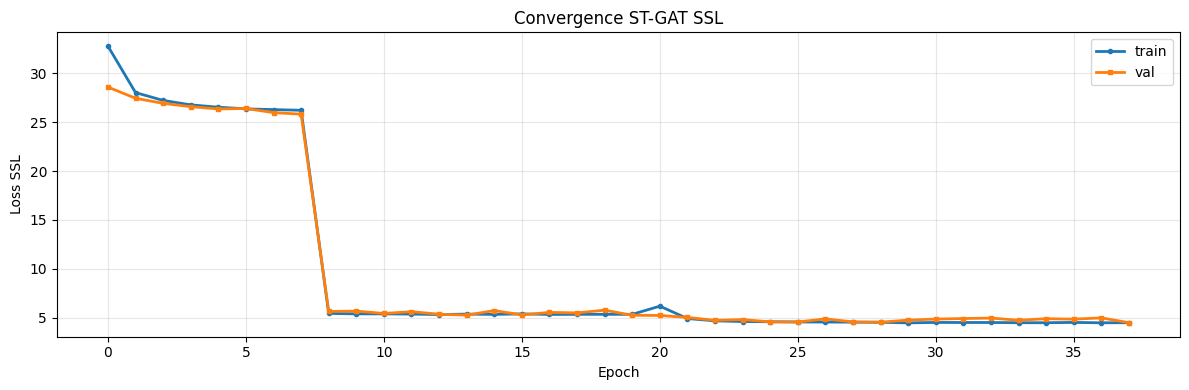

UMAP 2D...


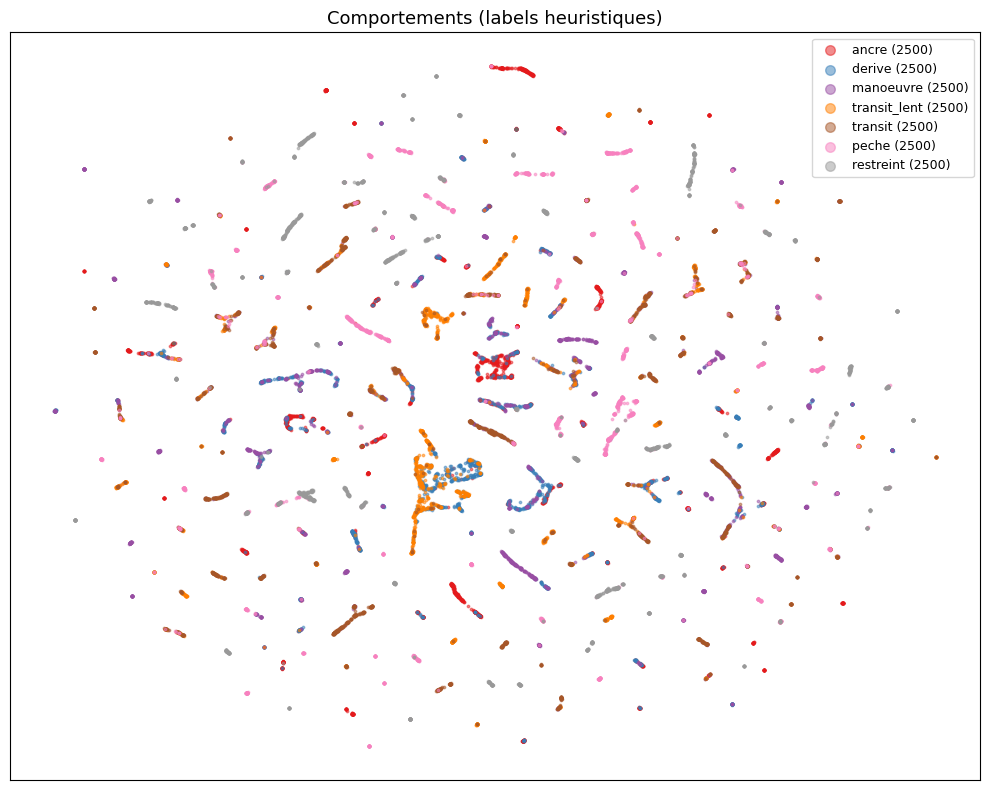

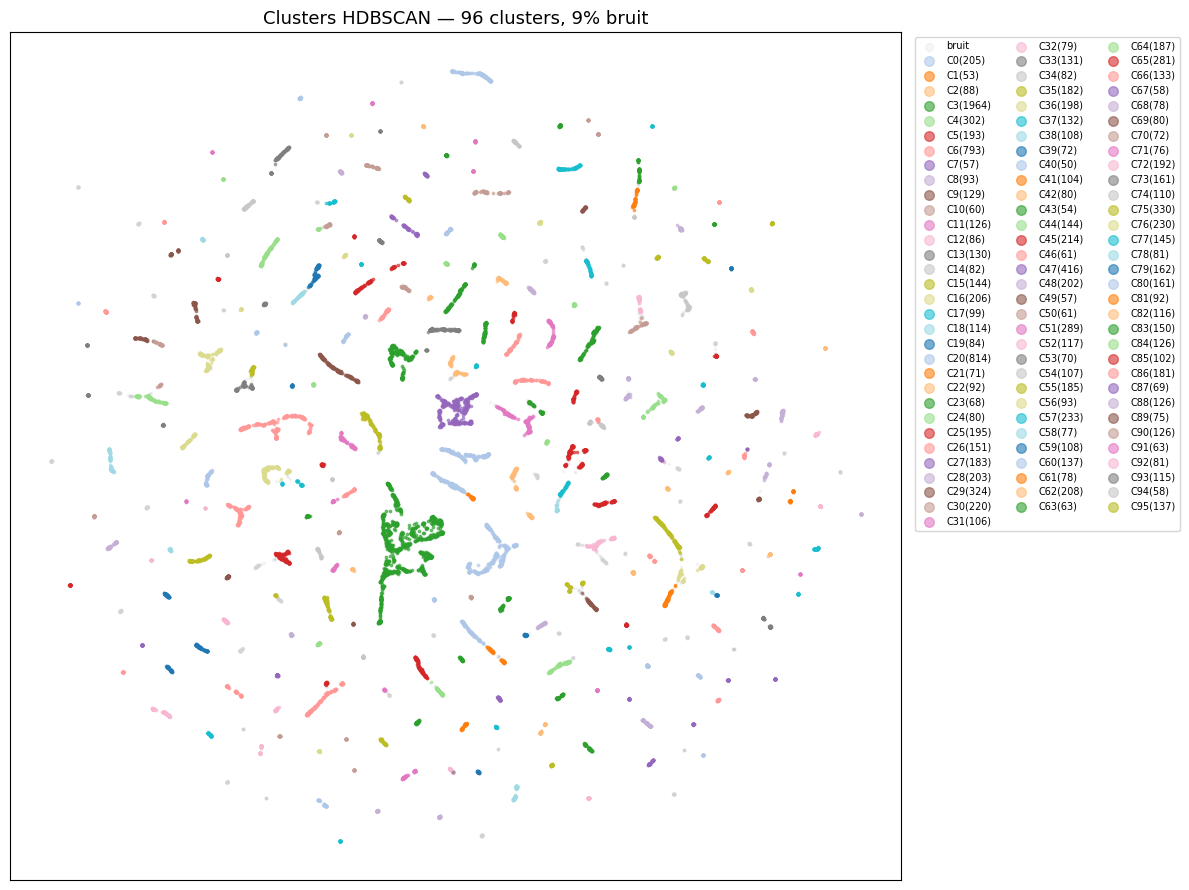

Sauvegarde : umap_behaviors.png + umap_clusters.png


In [24]:
# courbes d'apprentissage
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(history['train'], label='train', lw=2, marker='o', markersize=3)
ax.plot(history['val'],   label='val',   lw=2, marker='s', markersize=3)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss SSL')
ax.set_title('Convergence ST-GAT SSL')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_DIR / 'training_curves.png', dpi=150)
plt.show()

# UMAP
print('UMAP 2D...')
reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1,
                    random_state=SEED, low_memory=True)
X_umap = reducer.fit_transform(X_umap10)

# figure comportements
fig, ax = plt.subplots(figsize=(10, 8))
pal_beh = plt.cm.Set1(np.linspace(0, 1, len(beh_names)))
for i, name in enumerate(beh_names):
    m = y_beh == i
    if m.sum() > 0:
        ax.scatter(X_umap[m, 0], X_umap[m, 1], c=[pal_beh[i]],
                   label=f'{name} ({m.sum()})', s=3, alpha=0.5)
ax.set_title('Comportements (labels heuristiques)', fontsize=13)
ax.legend(markerscale=4, fontsize=9, loc='upper right',
          framealpha=0.8, ncol=1)
ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()
fig.savefig(OUT_DIR / 'umap_behaviors.png', dpi=150, bbox_inches='tight')
plt.show()

# figure clusters — legende en 3 colonnes pour 59 clusters
fig, ax = plt.subplots(figsize=(12, 9))
pal_cl = plt.cm.tab20(np.linspace(0, 1, 20))
for i, c in enumerate(sorted(set(labels))):
    m = labels == c
    if c == -1:
        ax.scatter(X_umap[m, 0], X_umap[m, 1], c='lightgray',
                   label='bruit', s=2, alpha=0.2)
    else:
        ax.scatter(X_umap[m, 0], X_umap[m, 1], c=[pal_cl[i % 20]],
                   label=f'C{c}({m.sum()})', s=3, alpha=0.6)
ax.set_title(f'Clusters HDBSCAN — {n_cl} clusters, {noise:.0f}% bruit', fontsize=13)
ax.legend(markerscale=4, fontsize=7, bbox_to_anchor=(1.01, 1),
          loc='upper left', ncol=3, framealpha=0.8)
ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()
fig.savefig(OUT_DIR / 'umap_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegarde : umap_behaviors.png + umap_clusters.png')

## 12. Anomalie par navire et interactions suspectes

In [25]:
def anomaly_score(mmsi_arr, cluster_arr, beh_arr):
    rows = []
    for m in np.unique(mmsi_arr):
        mask  = mmsi_arr == m
        cl    = cluster_arr[mask]
        if len(cl) < 5: continue
        noise_ratio = (cl == -1).mean()
        valid = cl[cl != -1]
        if len(valid) > 0:
            counts = np.bincount(valid + 1)
            probs  = counts / counts.sum()
            entropy = -np.sum(probs * np.log(probs + 1e-9))
        else:
            entropy = 0.0
        score = noise_ratio * 0.6 + (entropy / np.log(max(len(valid), 2))) * 0.4
        rows.append({'mmsi': m, 'n_seqs': len(cl),
                     'noise_ratio': round(noise_ratio, 3),
                     'entropy': round(float(entropy), 3),
                     'anomaly_score': round(float(score), 3)})
    return pd.DataFrame(rows).sort_values('anomaly_score', ascending=False)


anomaly_df = anomaly_score(mmsi_sel, labels, y_beh)
print('Top 20 navires anormaux :')
print(anomaly_df.head(20).to_string(index=False))
anomaly_df.to_csv(OUT_DIR / 'anomaly_scores.csv', index=False)


def detect_rendezvous(ais_df, dist_nm=0.5, speed_kt=3.0):
    """Detecte des paires de navires lents et proches (signal bunkering/transfert)."""
    ais_df = ais_df.copy()
    ais_df['t_bin'] = ais_df['t'].dt.floor('h')
    slow = ais_df[ais_df['speed_kt'] < speed_kt]
    pairs = []
    for _, grp in tqdm(slow.groupby('t_bin'), desc='Interactions'):
        vessels = grp.groupby('mmsi').agg(
            lon=('lon','median'), lat=('lat','median'), sog=('speed_kt','mean')
        ).reset_index()
        if len(vessels) < 2: continue
        for i in range(len(vessels)):
            for j in range(i+1, len(vessels)):
                va, vb = vessels.iloc[i], vessels.iloc[j]
                d = haversine_nm(va['lon'], va['lat'], vb['lon'], vb['lat'])
                if d < dist_nm:
                    pairs.append({
                        'mmsi_a': va['mmsi'], 'mmsi_b': vb['mmsi'],
                        't': grp['t_bin'].iloc[0],
                        'dist_nm': round(d, 3),
                        'sog_a': round(va['sog'], 2), 'sog_b': round(vb['sog'], 2),
                    })
    return pd.DataFrame(pairs)


interactions = detect_rendezvous(ais)
print(f'Interactions detectees : {len(interactions):,}')
if len(interactions) > 0:
    print(interactions.head(20).to_string(index=False))
    interactions.to_csv(OUT_DIR / 'interactions.csv', index=False)

Top 20 navires anormaux :
     mmsi  n_seqs  noise_ratio  entropy  anomaly_score
211135000       8        0.750    0.693          0.850
228301700       7        0.714    0.693          0.829
228827000      11        0.636    1.040          0.682
228165700       7        0.429    1.386          0.657
236213000      10        0.700    0.637          0.652
244740921       5        0.400    1.099          0.640
227704000      20        1.000    0.000          0.600
227330000      15        1.000    0.000          0.600
227114300      49        0.980   -0.000          0.588
227400510      16        0.938   -0.000          0.562
305370000       8        0.375    1.332          0.556
565494000      13        0.385    1.667          0.552
235081933       5        0.200    1.386          0.520
245334000       5        0.200    1.386          0.520
246644000       5        0.200    1.386          0.520
636016149      12        0.583    0.673          0.517
228263700       7        0.857   -0.000

: 

In [ ]:
# visualiser les trajectoires des 5 navires les plus anormaux
top5 = anomaly_df.head(5)['mmsi'].values

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, mmsi_v in enumerate(top5):
    track = ais[ais['mmsi'] == mmsi_v].sort_values('t')
    score = float(anomaly_df.loc[anomaly_df['mmsi'] == mmsi_v, 'anomaly_score'].iloc[0])
    country = ais.loc[ais['mmsi'] == mmsi_v, 'country'].iloc[0] if len(track) > 0 else 'unknown'
    
    axes[i].plot(track['lon'], track['lat'], 'b-', lw=1, alpha=0.6)
    axes[i].scatter(track['lon'].iloc[0],  track['lat'].iloc[0],
                    c='green', s=50, zorder=5, label='debut')
    axes[i].scatter(track['lon'].iloc[-1], track['lat'].iloc[-1],
                    c='red',   s=50, zorder=5, label='fin')
    axes[i].set_title(f'MMSI {mmsi_v}\n{country} | score={score:.2f}', fontsize=8)
    axes[i].set_xlabel('lon', fontsize=7)
    axes[i].set_ylabel('lat', fontsize=7)
    axes[i].grid(alpha=0.3)
    axes[i].legend(fontsize=6)

fig.suptitle('Trajectoires des 5 navires les plus anormaux', fontsize=12)
fig.tight_layout()
fig.savefig(OUT_DIR / 'anomaly_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()

# infos detaillees
print('Details navires anormaux :')
for mmsi_v in top5:
    track = ais[ais['mmsi'] == mmsi_v].sort_values('t')
    if len(track) == 0:
        continue
    print(f'\nMMSI : {mmsi_v}')
    print(f'  Pays       : {track["country"].iloc[0]}')
    print(f'  Type navire: {SHIP_CAT_NAMES.get(int(track["ship_cat"].iloc[0]), "unknown")}')
    print(f'  Messages   : {len(track)}')
    print(f'  Periode    : {track["t"].min()} -> {track["t"].max()}')
    print(f'  Speed moy  : {track["speed_kt"].mean():.1f} kt')
    print(f'  Zone       : lon [{track["lon"].min():.2f}, {track["lon"].max():.2f}]'
          f' lat [{track["lat"].min():.2f}, {track["lat"].max():.2f}]')

## 13. Resume

In [ ]:
print('=' * 60)
print('RESUME FINAL')
print('=' * 60)
print(f'Periodes temporelles : {len(TARGET_MONTHS)} x {DAYS_PER_PERIOD} jours')
print(f'Messages AIS         : {len(ais):,}')
print(f'Navires uniques      : {ais["mmsi"].nunique():,}')
print(f'Scenes 49D           : {len(scenes_49d):,}')
print(f'Sequences SSL 16D    : {len(sequences_16d):,}')
print(f'Best val loss        : {best_val:.5f}')
print(f'Clusters HDBSCAN     : {n_cl}')
print(f'Bruit HDBSCAN        : {noise:.1f}%')
print(f'Navires anomalie     : {len(anomaly_df)}')
print(f'Interactions         : {len(interactions)}')
print('='*60)
print('Fichiers :')
for f in sorted(OUT_DIR.glob('*')):
    print(f'  {f.name:<40} {f.stat().st_size/1e6:.1f} MB')

In [ ]:
print(f'Sequences : {len(sequences_norm)}')
print(f'Navires uniques : {meta_df["mmsi"].nunique()}')
print(f'Periodes couvertes : {ais["month"].unique()}')
print(f'Voisins moyens : {meta_df["n_neighbors"].mean():.2f}')

In [45]:
sample = pd.read_csv(
    BASE / 'AIS_DATA' / 'nari_dynamic.csv',
    usecols=['t'],
    nrows=5_000_000,
    dtype={'t': 'int64'}
)
sample['t'] = pd.to_datetime(sample['t'], unit='s', utc=True)
print('Mois disponibles dans les 5M premieres lignes :')
print(sample['t'].dt.month.value_counts().sort_index())
print(f'Min : {sample["t"].min()}')
print(f'Max : {sample["t"].max()}')
del sample

Mois disponibles dans les 5M premieres lignes :
t
9        5177
10    2520297
11    2474526
Name: count, dtype: int64
Min : 2015-09-30 22:00:02+00:00
Max : 2015-11-30 00:34:35+00:00
